# Dark Pattern Detection — Data Preparation and NLP EDA

This notebook is self-contained: it loads both prepared sources, maps labels,
deduplicates text, extracts the 12 selected features, runs EDA, and writes the
modelling table used by the later notebooks.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
from IPython.display import display
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")
print("Project root:", ROOT)

Project root: /Users/abhigoyal/Documents/Acadss/Data Science/Projects/dark-pattern-final


## 1. Load the two prepared data sources

In [2]:
raw_path = ROOT / "data/raw/dataset_raw.tsv"
extra_path = ROOT / "data/processed/collected.tsv"
dataset_path = ROOT / "data/processed/ccpa_dataset.tsv"
features_path = ROOT / "data/processed/features.csv"
assert raw_path.exists() and extra_path.exists()

raw_source = pd.read_csv(raw_path, sep="\t", on_bad_lines="skip", engine="python")
extra_source = pd.read_csv(extra_path, sep="\t", on_bad_lines="skip", engine="python")
display(pd.Series({
    "Yada et al. rows loaded": len(raw_source),
    "Additional CCPA rows loaded": len(extra_source),
}).to_frame("rows"))

,rows
Yada et al. rows loaded,2356
Additional CCPA rows loaded,4217


In [3]:
display(raw_source["Pattern Category"].value_counts().rename("rows").to_frame())
display(extra_source[["text", "Pattern Category"]].sample(5, random_state=42))

,rows
Pattern Category,
Not Dark Pattern,1178
Scarcity,418
Social Proof,312
Urgency,210
Misdirection,195
Obstruction,27
Sneaking,12
Forced Action,4


,text,Pattern Category
463,Advertised: water bottle for ₹1999.00. At chec...,Bait and Switch
2426,Uncheck to avoid not saving 15% on your water ...,Trick Question
2661,Cannot cancel Myntra online,Subscription Trap
1483,Insurance for your bluetooth speaker (₹25.00) ...,Basket Sneaking
2860,No thanks [Almost invisible link],Interface Interference


## 2. Map, combine, and deduplicate

Exact and punctuation-only variants are removed before any train/test split.

In [4]:
def map_to_ccpa(category, text):
    text = str(text).lower()
    if category == "Not Dark Pattern": return "Not a Dark Pattern"
    if category in ("Urgency", "Scarcity"): return "False Urgency"
    if category == "Social Proof": return "Disguised Advertisement"
    if category == "Misdirection":
        if any(x in text for x in ["no thanks", "i don't want", "prefer to pay", "hate saving", "i prefer"]):
            return "Confirm Shaming"
        if any(x in text for x in ["?", "yes,", "no,", "opt-in", "uncheck", "pre-checked"]):
            return "Trick Question"
        return "Interface Interference"
    if category == "Obstruction":
        return "Subscription Trap" if any(x in text for x in ["cancel", "membership", "subscription", "renew", "bill", "fee", "hotline"]) else "Interface Interference"
    if category == "Sneaking":
        return "Drip Pricing" if any(x in text for x in ["fee", "charge", "tax", "cost", "surcharge", "processing", "booking"]) else "Basket Sneaking"
    if category == "Forced Action": return "Forced Action"
    return "Not a Dark Pattern"

def normalise(text):
    return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9 ]+", " ", str(text).lower())).strip()

required = ["page_id", "text", "label", "Pattern Category"]
raw = raw_source.dropna(subset=["text", "Pattern Category"]).copy()
raw["Pattern Category"] = raw.apply(lambda r: map_to_ccpa(r["Pattern Category"], r["text"]), axis=1)
raw["label"] = (raw["Pattern Category"] != "Not a Dark Pattern").astype(int)

df = pd.concat([raw[required], extra_source[required]], ignore_index=True)
df["text"] = df["text"].astype(str).str.strip()
df = df.dropna(subset=required).loc[df["text"].str.len() >= 3]
before = len(df)
df = df.loc[~df["text"].map(normalise).duplicated()].reset_index(drop=True)
df["label"] = df["label"].astype(int)
df.to_csv(dataset_path, sep="\t", index=False)
print(f"Removed {before - len(df)} duplicates; kept {len(df):,} rows.")
display(df.head())

Removed 195 duplicates; kept 6,373 rows.


,page_id,text,label,Pattern Category
0,1012,FLASH SALE | LIMITED TIME ONLY Shop Now,1,False Urgency
1,158,Pillowcases & Shams,0,Not a Dark Pattern
2,108,Write a review,0,Not a Dark Pattern
3,1425,"To start your return, simply click on the foll...",0,Not a Dark Pattern
4,1658,newsletter signup (privacy policy),0,Not a Dark Pattern


In [5]:
assert df.columns.tolist() == required
assert df[required].isna().sum().sum() == 0
assert set(df["label"]) <= {0, 1}
assert not df["text"].map(normalise).duplicated().any()
print(f"Checks passed: {len(df):,} unique rows, {df['Pattern Category'].nunique()} classes.")

Checks passed: 6,373 unique rows, 14 classes.


## 3. Class balance and text-length EDA

,rows
Pattern Category,
Not a Dark Pattern,1855
False Urgency,493
Disguised Advertisement,476
Interface Interference,383
Subscription Trap,345
Basket Sneaking,326
Drip Pricing,326
Forced Action,324
Nagging,320


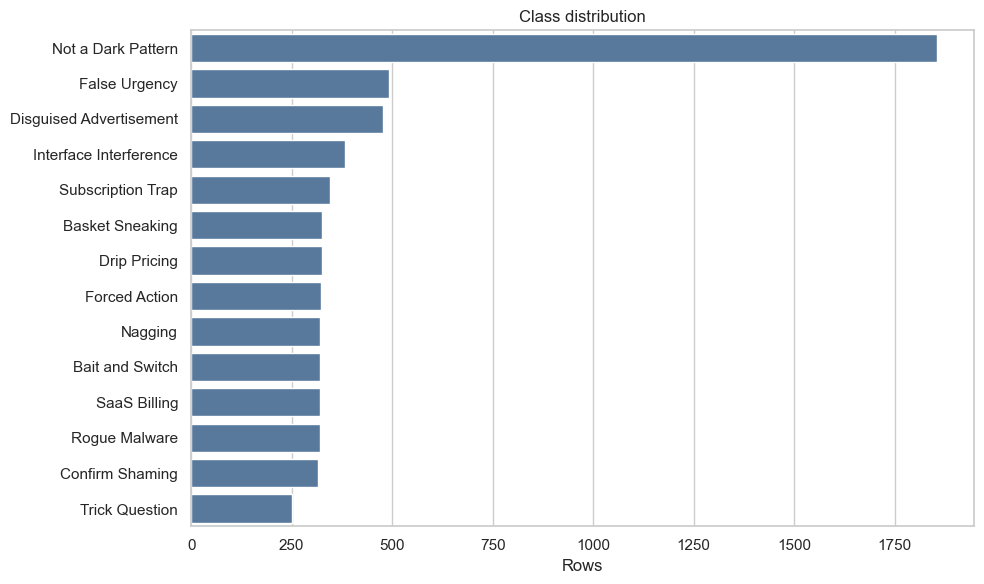

In [6]:
class_counts = df["Pattern Category"].value_counts()
display(class_counts.rename("rows").to_frame())
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=class_counts.values, y=class_counts.index, ax=ax, color="#4c78a8")
ax.set(title="Class distribution", xlabel="Rows", ylabel="")
plt.tight_layout(); plt.show()

,rows
label,
dark pattern,4518
benign,1855


,character_count,word_count
count,6373.00,6373.00
mean,51.08,8.64
std,45.68,7.56
min,3.00,1.00
25%,24.00,4.00
50%,42.00,7.00
75%,74.00,12.00
max,857.00,143.00


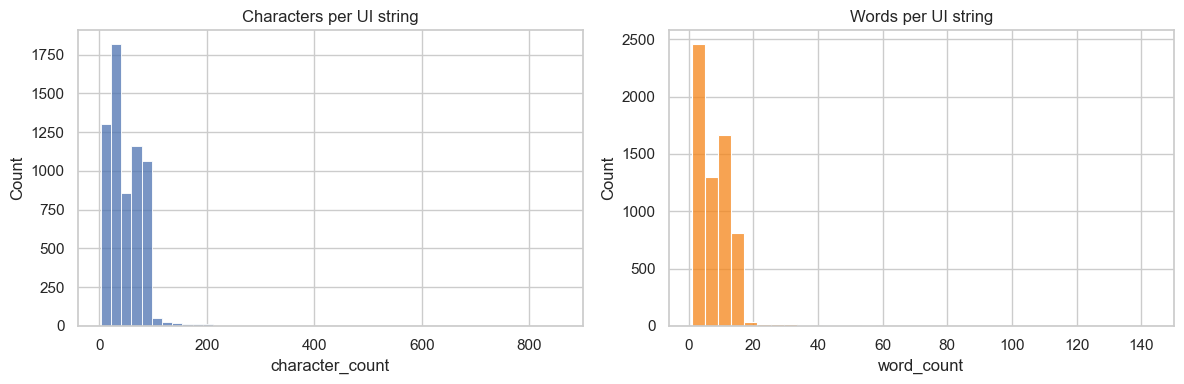

In [7]:
length_eda = df.assign(
    character_count=df["text"].str.len(),
    word_count=df["text"].str.split().str.len(),
)
display(df["label"].map({0: "benign", 1: "dark pattern"}).value_counts().to_frame("rows"))
display(length_eda[["character_count", "word_count"]].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(length_eda["character_count"], bins=45, ax=axes[0])
sns.histplot(length_eda["word_count"], bins=35, ax=axes[1], color="#f58518")
axes[0].set_title("Characters per UI string")
axes[1].set_title("Words per UI string")
plt.tight_layout(); plt.show()

## 4. Clean text and extract the 12 model features

In [8]:
NUM_COLS = ['urgency_kw_count', 'scarcity_kw_count', 'shame_phrase_flag', 'cancel_diff_score', 'social_proof_flag', 'price_drip_flag', 'discount_claim_flag', 'neg_option_flag', 'exclamation_count', 'question_count', 'number_present', 'time_reference_flag']

URGENCY = [r"hurry", r"limited time", r"ends in", r"only.*hours", r"today only", r"flash sale", r"act now", r"last chance", r"don't miss", r"expires", r"clock is ticking", r"ending soon", r"deal ends", r"final hours", r"sale ends", r"countdown", r"before it'?s gone"]
SCARCITY = [r"only \d+ left", r"low stock", r"selling fast", r"almost gone", r"high demand", r"\d+ remaining", r"last remaining", r"few left", r"running out", r"limited stock", r"\d+ in stock", r"nearly sold out"]
SHAME = [r"no thanks.*don't want", r"i don't need", r"no.*i prefer.*paying", r"no.*i hate", r"no thanks", r"prefer to pay", r"hate saving", r"dont want", r"i'?ll pay full", r"i don'?t like saving", r"no, i'?m fine paying"]
CANCEL = [r"to cancel.*call", r"email.*unsubscribe", r"to stop.*write", r"cancel.*call.*1-800", r"registered mail", r"hotline", r"loyalty department", r"chat with our live agent", r"cancellation fee", r"call.*to cancel", r"business hours", r"retention team"]
SOCIAL = [r"people.*viewing", r"people.*bought", r"added.*cart.*recently", r"watching this", r"others.*looking", r"purchased a", r"\d+ people", r"customers? are", r"booked in the last", r"sold in the last"]
PRICE = [r"processing fee", r"service charge", r"convenience fee", r"booking fee", r"taxes.*not included", r"resort fee", r"cleaning fee", r"handling cost", r"admin surcharge", r"handling fee", r"added at checkout", r"surcharge", r"not included in", r"extra fee"]
DISCOUNT = [r"\d+% off", r"save ₹", r"save \$", r"was.*now", r"you save", r"coupon", r"discount", r"deal", r"offer"]
NEGATIVE_OPTION = [r"pre-ticked", r"opted in", r"already selected", r"auto-renew", r"pre-selected", r"checked by default", r"pre-checked", r"automatically renew", r"auto-debit", r"uncheck", r"leave.*box.*unchecked"]

for package in ["punkt", "punkt_tab", "wordnet", "omw-1.4"]:
    nltk.download(package, quiet=True)
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    tokens = word_tokenize(re.sub(r"[^a-zA-Z\s!?]", "", str(text).lower()))
    return " ".join(lemmatizer.lemmatize(token) for token in tokens)

def extract_features(text):
    text, low = str(text), str(text).lower()
    return {
        "urgency_kw_count": sum(bool(re.search(x, low)) for x in URGENCY),
        "scarcity_kw_count": sum(bool(re.search(x, low)) for x in SCARCITY),
        "shame_phrase_flag": int(any(re.search(x, low) for x in SHAME)),
        "cancel_diff_score": sum(bool(re.search(x, low)) for x in CANCEL),
        "social_proof_flag": int(any(re.search(x, low) for x in SOCIAL)),
        "price_drip_flag": int(any(re.search(x, low) for x in PRICE)),
        "discount_claim_flag": int(any(re.search(x, low) for x in DISCOUNT)),
        "neg_option_flag": int(any(re.search(x, low) for x in NEGATIVE_OPTION)),
        "exclamation_count": text.count("!"),
        "question_count": text.count("?"),
        "number_present": int(bool(re.search(r"\d+", text))),
        "time_reference_flag": int(bool(re.search(r"hour|minute|day|tonight|today|soon|week|month|year", low))),
    }

assert list(extract_features("Only 2 left today!")) == NUM_COLS
display(pd.DataFrame({"model_feature": NUM_COLS}))

,model_feature
0,urgency_kw_count
1,scarcity_kw_count
2,shame_phrase_flag
3,cancel_diff_score
4,social_proof_flag
5,price_drip_flag
6,discount_claim_flag
7,neg_option_flag
8,exclamation_count
9,question_count


In [9]:
feature_frame = pd.DataFrame([extract_features(text) for text in df["text"]], columns=NUM_COLS)
df_features = pd.concat([
    df[required],
    df["text"].map(clean_text).rename("clean_text"),
    feature_frame,
], axis=1)
expected_columns = required + ["clean_text"] + NUM_COLS
assert df_features.columns.tolist() == expected_columns
assert not df_features[NUM_COLS].isna().any().any()
print("Feature table shape:", df_features.shape)
display(df_features.head())

Feature table shape: (6373, 17)


,page_id,text,label,Pattern Category,clean_text,urgency_kw_count,scarcity_kw_count,shame_phrase_flag,cancel_diff_score,social_proof_flag,price_drip_flag,discount_claim_flag,neg_option_flag,exclamation_count,question_count,number_present,time_reference_flag
0,1012,FLASH SALE | LIMITED TIME ONLY Shop Now,1,False Urgency,flash sale limited time only shop now,2,0,0,0,0,0,0,0,0,0,0,0
1,158,Pillowcases & Shams,0,Not a Dark Pattern,pillowcase sham,0,0,0,0,0,0,0,0,0,0,0,0
2,108,Write a review,0,Not a Dark Pattern,write a review,0,0,0,0,0,0,0,0,0,0,0,0
3,1425,"To start your return, simply click on the foll...",0,Not a Dark Pattern,to start your return simply click on the follo...,0,0,0,0,0,0,0,0,0,0,0,0
4,1658,newsletter signup (privacy policy),0,Not a Dark Pattern,newsletter signup privacy policy,0,0,0,0,0,0,0,0,0,0,0,0


## 5. Inspect the selected signals

In [10]:
display(df_features[NUM_COLS].describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
urgency_kw_count,6373.0,0.043,0.234,0.0,0.0,0.0,0.0,3.0
scarcity_kw_count,6373.0,0.027,0.172,0.0,0.0,0.0,0.0,2.0
shame_phrase_flag,6373.0,0.039,0.194,0.0,0.0,0.0,0.0,1.0
cancel_diff_score,6373.0,0.027,0.216,0.0,0.0,0.0,0.0,2.0
social_proof_flag,6373.0,0.021,0.145,0.0,0.0,0.0,0.0,1.0
price_drip_flag,6373.0,0.015,0.122,0.0,0.0,0.0,0.0,1.0
discount_claim_flag,6373.0,0.095,0.293,0.0,0.0,0.0,0.0,1.0
neg_option_flag,6373.0,0.046,0.210,0.0,0.0,0.0,0.0,1.0
exclamation_count,6373.0,0.096,0.333,0.0,0.0,0.0,0.0,4.0
question_count,6373.0,0.021,0.145,0.0,0.0,0.0,0.0,1.0


,share_above_zero
number_present,51.7%
time_reference_flag,14.1%
discount_claim_flag,9.5%
exclamation_count,8.5%
neg_option_flag,4.6%
shame_phrase_flag,3.9%
urgency_kw_count,3.7%
scarcity_kw_count,2.5%
social_proof_flag,2.1%
question_count,2.1%


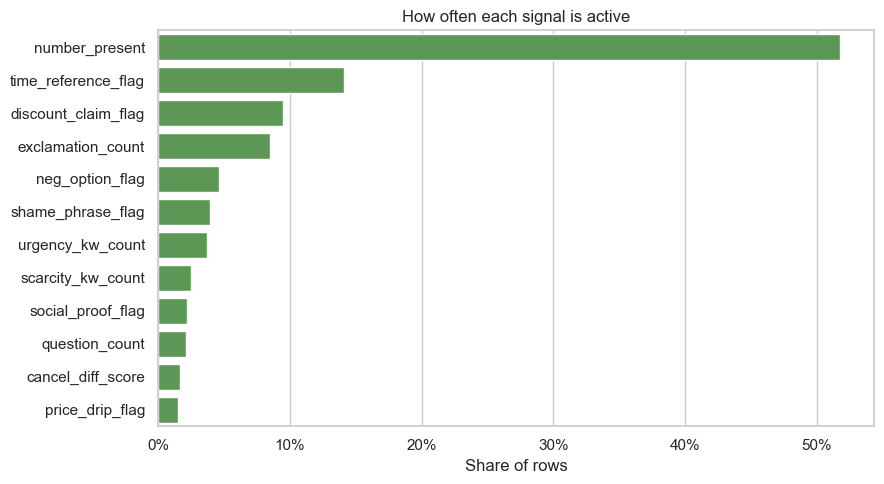

In [11]:
signal_rate = (df_features[NUM_COLS] > 0).mean().sort_values(ascending=False)
display(signal_rate.rename("share_above_zero").to_frame().style.format("{:.1%}"))
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=signal_rate.values, y=signal_rate.index, ax=ax, color="#54a24b")
ax.set(title="How often each signal is active", xlabel="Share of rows", ylabel="")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout(); plt.show()

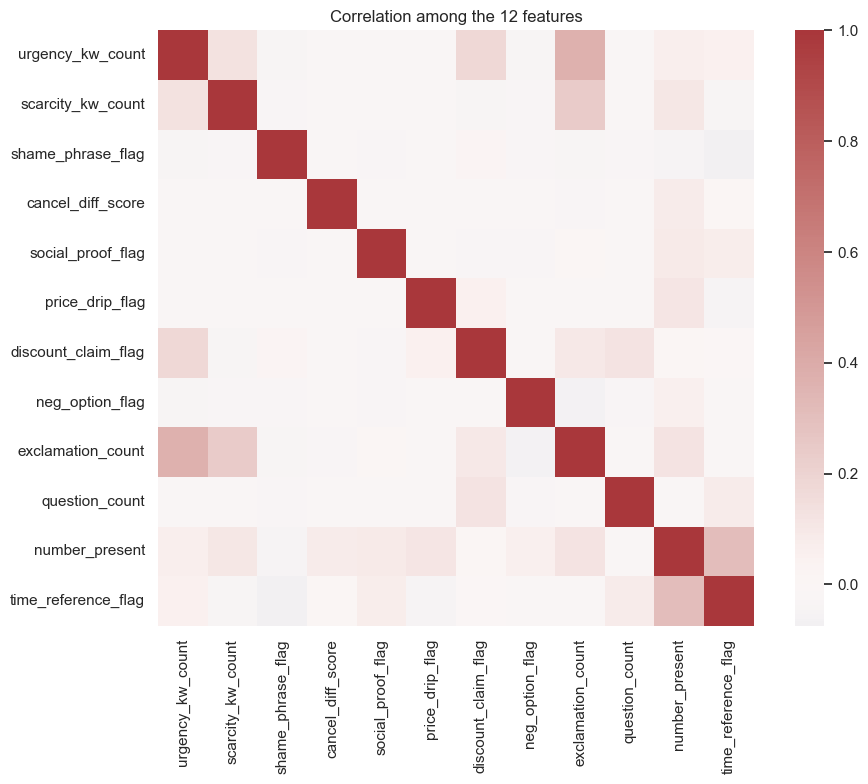

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_features[NUM_COLS].corr(), cmap="vlag", center=0, square=True, ax=ax)
ax.set_title("Correlation among the 12 features")
plt.tight_layout(); plt.show()

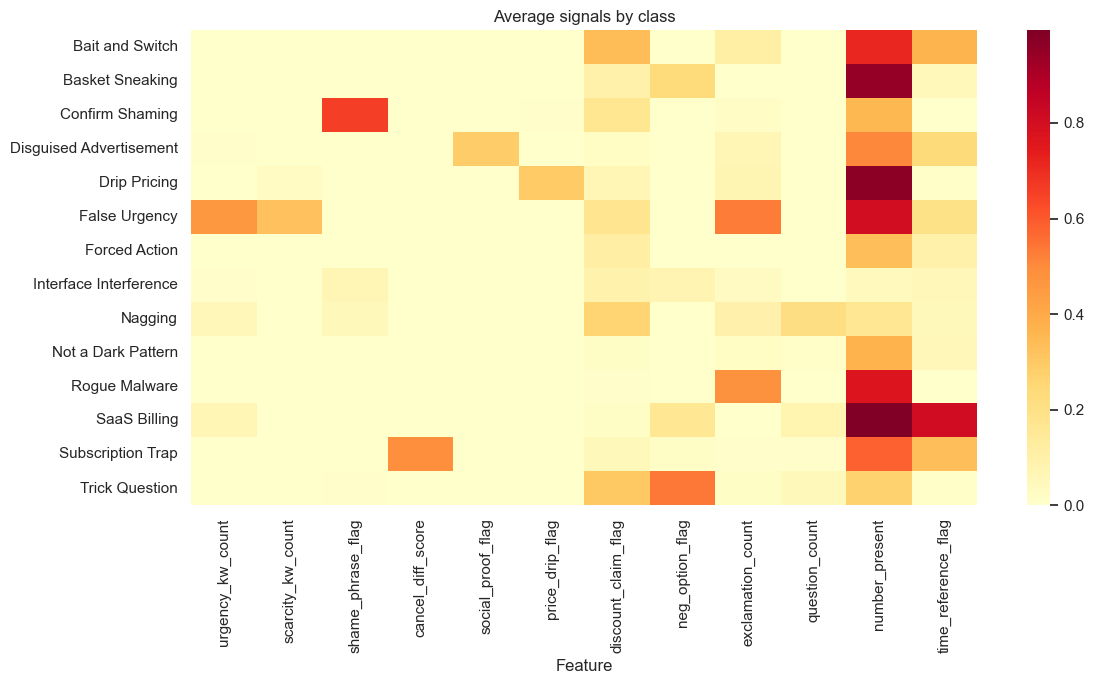

In [13]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(df_features.groupby("Pattern Category")[NUM_COLS].mean(), cmap="YlOrRd", ax=ax)
ax.set(title="Average signals by class", xlabel="Feature", ylabel="")
plt.tight_layout(); plt.show()

## 6. Save the modelling table

In [14]:
df_features.to_csv(features_path, index=False)
saved = pd.read_csv(features_path)
assert saved.columns.tolist() == expected_columns and saved.shape == df_features.shape
assert saved[required].astype(str).equals(df_features[required].astype(str))
print(f"Saved {saved.shape[0]:,} rows x {saved.shape[1]} columns to {features_path.relative_to(ROOT)}")

Saved 6,373 rows x 17 columns to data/processed/features.csv


## What I found

- The final table contains 6,373 unique strings across 14 classes.
- The classes are imbalanced, so later notebooks use grouped macro-F1.
- Only the selected 12 engineered columns are saved; character TF-IDF handles the wider wording.